In [1]:
%matplotlib inline

# Problem Set 10 — Inferring cosmology from the Planck CMB spectrum with NPE

We infer the matter and baryon densities $(\Omega_m, \Omega_b)$ around their fiducial Planck 2018
values $\Omega_m = 0.3153 \pm 0.0073$, $\Omega_b = 0.0494 \pm 0.0003$ (i.e.
$\Omega_b h^2 = 0.02238 \pm 0.00015$). The $\pm$ values are the Planck 2018 $1\sigma$ errors, and
the uniform prior spans $\pm 4\sigma$ around the fiducial. All other parameters are held fixed:
$H_0 = 67.32$ km/s/Mpc, $n_s = 0.9661$, $\ln(10^{10}A_s) = 3.045$, $\tau = 0.0543$.


## 0. Setup

In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import torch

from sbi.inference import NPE
from sbi.utils import BoxUniform
from sbi.diagnostics import run_sbc, check_sbc

from make_planck_npe_data import load_planck_npe_data

%matplotlib inline
torch.set_default_dtype(torch.float32)
torch.manual_seed(7)
rng = np.random.default_rng(7)

theta_labels = [r"$\Omega_m$", r"$\Omega_b$"]
print("setup ok")

setup ok


## 1. Load the simulations  *(Task 1)*

We load the training bank from `planck_camb_tt.h5` and set up the prior. The file holds
`theta` $=(\Omega_m,\Omega_b)$ and the corresponding **clean** (noise-free) CAMB spectra
`spectra`, plus the multipoles `ell`, the fiducial cosmology, and the Planck observation
(used later).

In [5]:
data = load_planck_npe_data()

theta = torch.as_tensor(data.theta, dtype=torch.float32)        # (n, 2)
spectra = torch.as_tensor(data.spectra, dtype=torch.float32)    # (n, n_ell), CLEAN
ell = data.ell
fid_theta = data.fid_theta
fid_spectrum = data.fid_spectrum

prior = BoxUniform(low=torch.as_tensor(data.prior_low, dtype=torch.float32),
                   high=torch.as_tensor(data.prior_high, dtype=torch.float32))

n_sims, n_features = spectra.shape
print(f"{n_sims} simulations, {n_features} multipoles, ell in [{ell.min():.0f}, {ell.max():.0f}]")
print("prior low :", np.asarray(data.prior_low))
print("prior high:", np.asarray(data.prior_high))
print("fiducial  :", fid_theta)

2000 simulations, 1499 multipoles, ell in [2, 1500]
prior low : [0.2861     0.04806506]
prior high: [0.3445     0.05071291]
fiducial  : [0.3153     0.04938898]


## 2. Plot the prior-predictive spectra  *(Task 2)*

We plot a random sample (40) of the clean training spectra and overlay the fiducial spectrum, to
see how much the spectrum moves as $(\Omega_m,\Omega_b)$ vary across the prior.

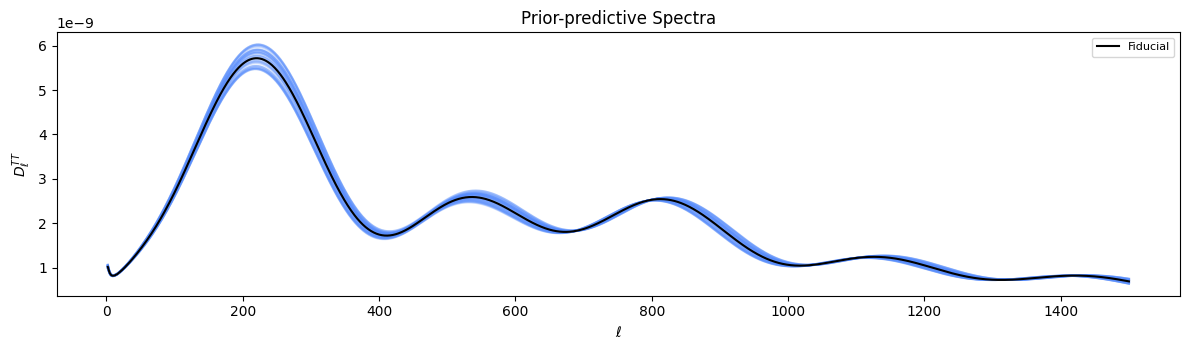

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3.6))

idx = rng.choice(n_sims, size=40, replace=False)
for j in idx:
    ax.plot(ell, spectra[j].numpy(), color="C0", alpha=0.25)

ax.plot(ell, fid_spectrum, "k-", label=r"Fiducial")
ax.legend(fontsize=8)
ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$D_\ell^{TT}$")
ax.set_title("Prior-predictive Spectra")
plt.tight_layout()

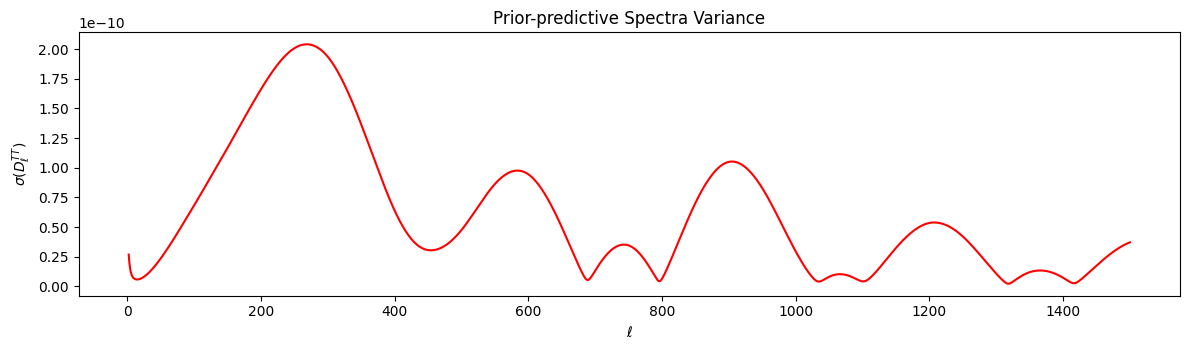

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3.6))
ax.plot(ell, np.std(spectra[idx].numpy(), axis=0), color = 'r')
ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$\sigma(D_\ell^{TT})$")
ax.set_title("Prior-predictive Spectra Variance")
plt.tight_layout()

## 3. Load the Planck data  *(Task 3)*

We extract the official unbinned Planck TT observation from `data` and plot it with its error bars,
together with the fiducial CAMB spectrum. We will infer the cosmology from exactly this data
vector in Task 6.

In [8]:
planck_dl, planck_err_minus, planck_err_plus = data.planck_dl, data.planck_err_minus, data.planck_err_plus
planck_sigma = data.planck_sigma

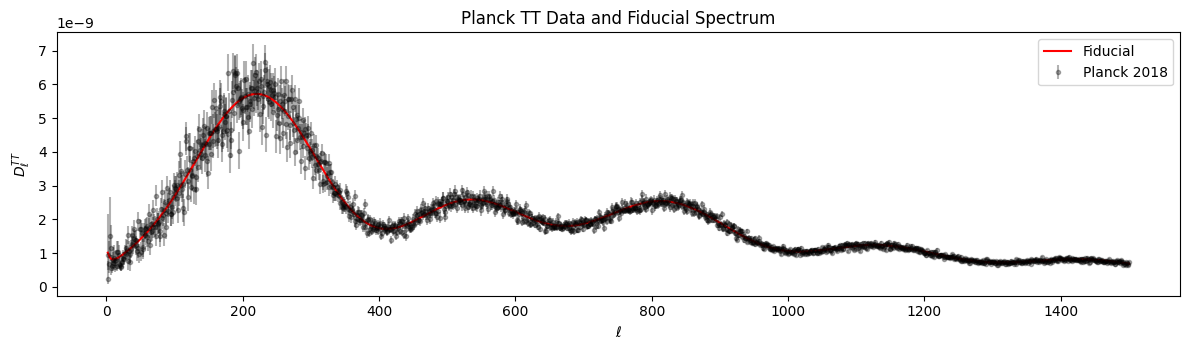

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3.6))
plt.errorbar(ell, planck_dl, yerr=[planck_err_minus, planck_err_plus], label="Planck 2018", color="k", fmt=".", alpha=0.3)
plt.plot(ell, fid_spectrum, "r", label="Fiducial")
plt.legend()
plt.xlabel(r"$\ell$"); plt.ylabel(r"$D_\ell^{TT}$")
plt.title("Planck TT Data and Fiducial Spectrum")
plt.tight_layout()

## 4. Add measurement errors — cosmic variance  *(Task 4)*

The shipped spectra are **noise-free**. We build a diagonal noise model and apply it to every training
spectrum, so the network learns from data that look like the real, noisy Planck observation.

The per-multipole variance is cosmic variance (which **scales with the spectrum**, Knox formula)
plus a fixed instrument floor:

$$\sigma_\ell^2(\theta) = \underbrace{\frac{2}{(2\ell+1)\,f_{\rm sky}}\,D_\ell(\theta)^2}_{\text{cosmic variance}} + \sigma_{{\rm floor},\ell}^2 .$$

Calibrate the floor **once** so the fiducial cosmology reproduces the Planck error bars:
$\sigma_{{\rm floor},\ell}^2 = \max\!\big(\sigma_\ell^{\rm Planck\,2} - \sigma_{\rm cv}(D_\ell^{\rm fid})^2,\,0\big)$.
Then we standardize the features $(x-\mu)/\sigma$ before training.

In [10]:
F_SKY = 1.0

cosmic_variance_k = np.sqrt(2 / ((2 * ell + 1) * F_SKY))
cosmic_variance_sigma = cosmic_variance_k * fid_spectrum

sigma_floor = np.sqrt(np.clip(planck_sigma ** 2 - cosmic_variance_sigma ** 2, 0, None))

def add_noise(clean, cv_k=0, sigma_floor=0):
    sigma_floor = torch.as_tensor(sigma_floor)
    return clean + torch.randn_like(clean) * torch.sqrt(sigma_floor ** 2 + torch.as_tensor(cv_k) ** 2  * clean**2)


In [11]:
noisy_spectra = add_noise(spectra, cosmic_variance_k, sigma_floor)

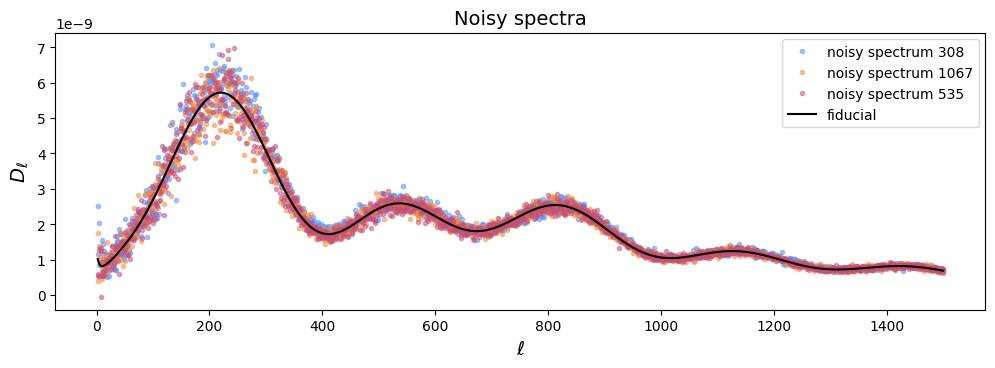

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3.6))
idx = rng.choice(n_sims, size=3, replace=False)
for j in idx:
    ax.plot(ell, noisy_spectra[j].numpy(), marker='.', ls='', label=f"noisy spectrum {j}", alpha=0.5)

ax.plot(ell, fid_spectrum, "k-", label="fiducial")
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$D_\ell$", fontsize=14)
ax.set_title("Noisy spectra", fontsize=14)
ax.legend()

In [13]:
sigmas = torch.std(noisy_spectra, dim=0)
mus = torch.mean(noisy_spectra, dim=0)

x = (noisy_spectra-mus)/sigmas

## 5. Train the NPE  *(Task 5)*

We train an amortized NPE and
hold out the **last `n_test = 300`** simulations — we will use them for the coverage test in Task 7.

In [14]:
n_test = 300

inference = NPE(prior=prior)
estimator = inference.append_simulations(theta, x).train(max_num_epochs=120)
posterior = inference.build_posterior(estimator)
# Hold out the LAST n_test=300 simulations for the coverage check in Task 7:
theta_train, x_train = theta[:-n_test], x[:-n_test]

 Neural network successfully converged after 26 epochs.

## 6. Posterior for the Planck spectrum  *(Task 6)*

In [15]:
from scipy.ndimage import gaussian_filter

def credible_levels_from_samples(samples, bins=80, masses=(0.95, 0.68)):
    H, xe, ye = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins, density=True)
    H = gaussian_filter(H.T, sigma=1.2)
    dx, dy = xe[1] - xe[0], ye[1] - ye[0]
    flat = np.sort(H.ravel())[::-1]
    csum = np.cumsum(flat) * dx * dy
    levels = sorted(flat[min(np.searchsorted(csum, m), len(flat) - 1)] for m in masses)
    xc, yc = 0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:])
    X, Y = np.meshgrid(xc, yc)
    return X, Y, H, levels

def draw_posterior(samples, truth=None, truth_err=None, title="Posterior"):
    samples = np.asarray(samples)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    X, Y, H, levels = credible_levels_from_samples(samples)
    axes[0].contour(X, Y, H, levels=levels, colors=["tab:blue", "navy"], linewidths=[1.2, 1.8])
    axes[0].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.03, color="tab:blue", rasterized=True)
    if truth is not None:
        if truth_err is not None:
            axes[0].errorbar(truth[0], truth[1], xerr=truth_err[0], yerr=truth_err[1],
                             fmt="r*", ms=13, ecolor="r", capsize=3, label="Planck 2018")
        else:
            axes[0].plot(truth[0], truth[1], "r*", ms=13, label="fiducial")
        axes[0].legend(fontsize=8)
    axes[0].set_xlabel(theta_labels[0]); axes[0].set_ylabel(theta_labels[1]); axes[0].set_title(title)
    for j, ax in enumerate(axes[1:]):
        ax.hist(samples[:, j], bins=60, density=True, color="tab:blue", alpha=0.65)
        if truth is not None:
            ax.axvline(truth[j], color="r", ls=":", lw=2)
            if truth_err is not None:
                ax.axvspan(truth[j] - truth_err[j], truth[j] + truth_err[j], color="r", alpha=0.12)
        ax.set_xlabel(theta_labels[j]); ax.set_ylabel("density")
    plt.tight_layout()
    return fig, axes

Now we sample the posterior at the Planck data vector and plot it. We mark the Planck 2018 fiducial
with its published 1-$\sigma$ error bars.

In [16]:
omega_b_sigma = 0.00015 / data.h**2 ; truth_err = [0.0073, omega_b_sigma]

In [17]:
x_planck = ((torch.as_tensor(planck_dl, dtype=torch.float32) - mus)/sigmas).reshape(1, -1)
planck_samples = posterior.sample((20000,), x=x_planck, show_progress_bars=False).numpy()

In [18]:
credible_levels_from_samples(planck_samples, bins=80, masses=(0.95, 0.68))

(array([[0.29925105, 0.29962075, 0.29999042, ..., 0.32771626, 0.32808596,
         0.32845563],
        [0.29925105, 0.29962075, 0.29999042, ..., 0.32771626, 0.32808596,
         0.32845563],
        [0.29925105, 0.29962075, 0.29999042, ..., 0.32771626, 0.32808596,
         0.32845563],
        ...,
        [0.29925105, 0.29962075, 0.29999042, ..., 0.32771626, 0.32808596,
         0.32845563],
        [0.29925105, 0.29962075, 0.29999042, ..., 0.32771626, 0.32808596,
         0.32845563],
        [0.29925105, 0.29962075, 0.29999042, ..., 0.32771626, 0.32808596,
         0.32845563]], shape=(80, 80), dtype=float32),
 array([[0.04808185, 0.04808185, 0.04808185, ..., 0.04808185, 0.04808185,
         0.04808185],
        [0.04811494, 0.04811494, 0.04811494, ..., 0.04811494, 0.04811494,
         0.04811494],
        [0.04814804, 0.04814804, 0.04814804, ..., 0.04814804, 0.04814804,
         0.04814804],
        ...,
        [0.05063013, 0.05063013, 0.05063013, ..., 0.05063013, 0.05063013,
   

(<Figure size 1200x360 with 3 Axes>,
 array([<Axes: title={'center': 'Posterior'}, xlabel='$\\Omega_m$', ylabel='$\\Omega_b$'>,
        <Axes: xlabel='$\\Omega_m$', ylabel='density'>,
        <Axes: xlabel='$\\Omega_b$', ylabel='density'>], dtype=object))

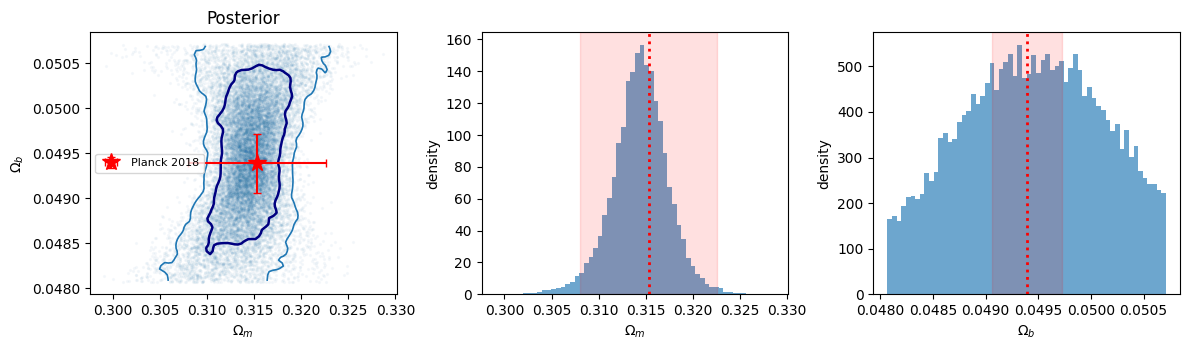

In [19]:
draw_posterior(planck_samples, truth=fid_theta, truth_err=truth_err, title="Posterior")

## 7. Checks — coverage & posterior predictive  *(Task 7)*
We perform one check whether the neural posterior returns trustful answer.

**Coverage / SBC.** On the held-out simulations (`theta[-n_test:]`, `x_all[-n_test:]`), we run
simulation-based calibration, werank each true value among posterior draws. Flat rank histograms =
calibrated; $\cup$-shaped = overconfident.

In [20]:
ranks, dap = run_sbc(theta_train, x_train, posterior, num_posterior_samples=200)

Drawing 200 samples for 1700 observations: 201it [02:26,  1.37it/s]                         
Calculating ranks for 1700 SBC samples: 100%|██████████| 1700/1700 [00:00<00:00, 23502.54it/s]


In [21]:
ks = check_sbc(ranks, theta_train, dap, num_posterior_samples=200)["ks_pvals"]
print(ks)

tensor([1.2576e-38, 1.5738e-02])


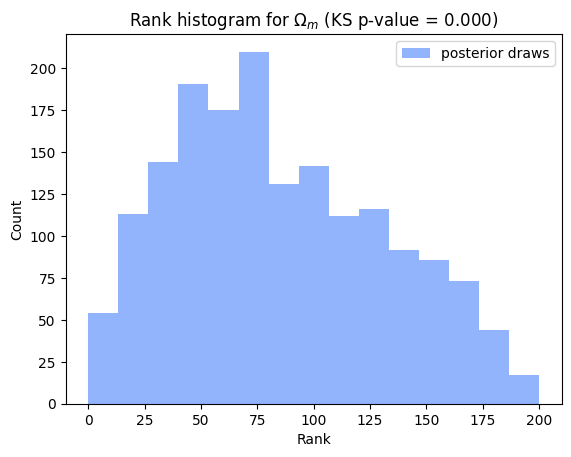

In [22]:
plt.figure()
plt.hist(ranks[:,0], bins=15, range=(0, 200), label="posterior draws", alpha=0.65)
plt.title(f"Rank histogram for {theta_labels[0]} (KS p-value = {ks[0]:.3f})")
plt.xlabel("Rank"); plt.ylabel("Count"); plt.legend(); plt.show()

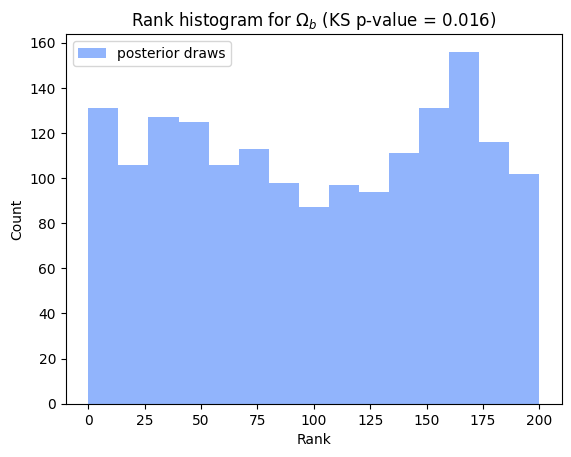

In [23]:
plt.figure()
plt.hist(ranks[:,1], bins=15, range=(0, 200), label="posterior draws", alpha=0.65)
plt.title(f"Rank histogram for {theta_labels[1]} (KS p-value = {ks[1]:.3f})")
plt.xlabel("Rank"); plt.ylabel("Count"); plt.legend(); plt.show()